# Code for S&P 2025

## Paper: Out of Sync? Analyzing Tactical Divides between Attackers and Defenders

### by Johannes Grill, Daniel Oberhofer and Philip Empl (University of Regensburg, Germany)

Attackers and defenders are in a constant race–while defenders must secure everything, attackers only need to exploit a single vulnerability. For organizations, having effective incident response processes and playbooks is crucial. But how can they be sure they are truly prepared? To guide them, we analyze 255,874 documented vulnerabilities, identifying the attack techniques commonly used by adversaries. We also examine and map 1,217 incident response playbooks to highlight the defensive techniques most frequently recommended by SOAR vendors. By aligning these two perspectives, we offer a clearer comparison between attacker strategies and defender responses. Our findings reveal that techniques X, Y, and Z dominate the vulnerability landscape, while defensive playbooks tend to focus on techniques A, B, and C. This misalignment has significant implications: organizations should adopt our proposed set of playbooks to bridge these gaps, and SOAR vendors must enhance their offerings to provide more comprehensive coverage. As it stands, attackers and defenders remain out of sync.


## Prerequisites

In [2]:
!pip install matplotlib-venn
!pip install kaggle
!pip install stix2 
!pip install taxii2-client
!pip install six
!pip install attackcti
!pip install tqdm

import os
import ast
import zipfile
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import numpy as np
# Additional imports for the new analyses
import plotly.express as px  # For fancy charts like treemaps and donut charts
import plotly.graph_objs as go  # For chord diagrams and advanced plotting
from matplotlib_venn import venn2  # For Venn diagrams, if needed
from sklearn.preprocessing import MultiLabelBinarizer
from tqdm import tqdm
import statsmodels.api as sm
import plotly.express as px


# PART A: Analyzing Attackers' Behavior

## A.1 Download our compiled attacker data from Kaggle
First, we need to load the data from the merged CSV file and prepare it for analysis.

In [5]:
# Step 2: Define the dataset identifier
dataset_identifier = 'philipempl/attacker-data'  # Replace with your dataset identifier

# Step 3: Create a directory to store the dataset
os.makedirs('kaggle_dataset', exist_ok=True)

# Step 4: Download the dataset
!kaggle datasets download -d {dataset_identifier} -p kaggle_dataset --force

# Step 5: List all downloaded files
downloaded_files = os.listdir('kaggle_dataset')

# Step 6: Extract all zip files in the directory
for file_name in downloaded_files:
    if file_name.endswith('.zip'):
        with zipfile.ZipFile(os.path.join('kaggle_dataset', file_name), 'r') as zip_ref:
            zip_ref.extractall('kaggle_dataset')

df = pd.read_csv('kaggle_dataset/results.csv')
df.head()

Dataset URL: https://www.kaggle.com/datasets/philipempl/attacker-data
License(s): other
 98%|█████████████████████████████████████▍| 68.0M/69.1M [00:06<00:00, 16.0MB/s]
100%|██████████████████████████████████████| 69.1M/69.1M [00:06<00:00, 11.6MB/s]


,cve_id,description,publisher,published_date,cvss_version,cvss_vector,cvss_score,impact_score,exploitability_score,epss_score,cpe_strings,attack_tactic,attack_technique,similarity,attack_mitigation,defend_tactic,defend_technique
0,CVE-2023-0001,An information exposure vulnerability in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:H/UI:N/S:U/C:H/I:H/A:H,6.7,5.9,0.8,False,[],NaN,NaN,NaN,NaN,NaN,NaN
1,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,[],['defense-evasion'],T1066,0.504643,[],[],[]
2,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,[],"['defense-evasion', 'persistence', 'privilege-...",T1150,0.527298,['M1022'],['Harden'],['D3-LFP']
3,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,[],['defense-evasion'],T1089,0.515254,"['M1018', 'M1018', 'M1018', 'M1022']","['Harden', 'Isolate', 'Harden', 'Harden']","['D3-LFP', 'D3-MAC', 'D3-SCP', 'D3-LFP']"
4,CVE-2023-0002,A problem with a protection mechanism in the P...,psirt@paloaltonetworks.com,2023-02-08T18:15Z,3.1,CVSS:3.1/AV:L/AC:L/PR:L/UI:N/S:U/C:H/I:H/A:H,7.8,5.9,1.8,False,[],"['persistence', 'privilege-escalation']",T1547.011,0.527298,['M1022'],['Harden'],['D3-LFP']


## A.2 Descriptive statistics for CVEs

In [7]:
print(len(df))

1126999


In [8]:
df.describe().apply(lambda s: s.apply(lambda x: format(x, 'g')))

,cvss_version,cvss_score,impact_score,exploitability_score,similarity
count,1.127e+06,1.06106e+06,1.06106e+06,1.06106e+06,1.02276e+06
mean,2.65004,6.81538,4.86368,4.59138,0.574037
std,0.525293,1.90275,2.04411,3.00806,0.0669342
min,2,0,0,0.1,0.5
25%,2,5.4,2.9,2.3,0.523045
50%,3,7.2,5.2,3.9,0.554517
75%,3.1,7.8,5.9,8,0.605767
max,3.1,10,10,10,0.967523


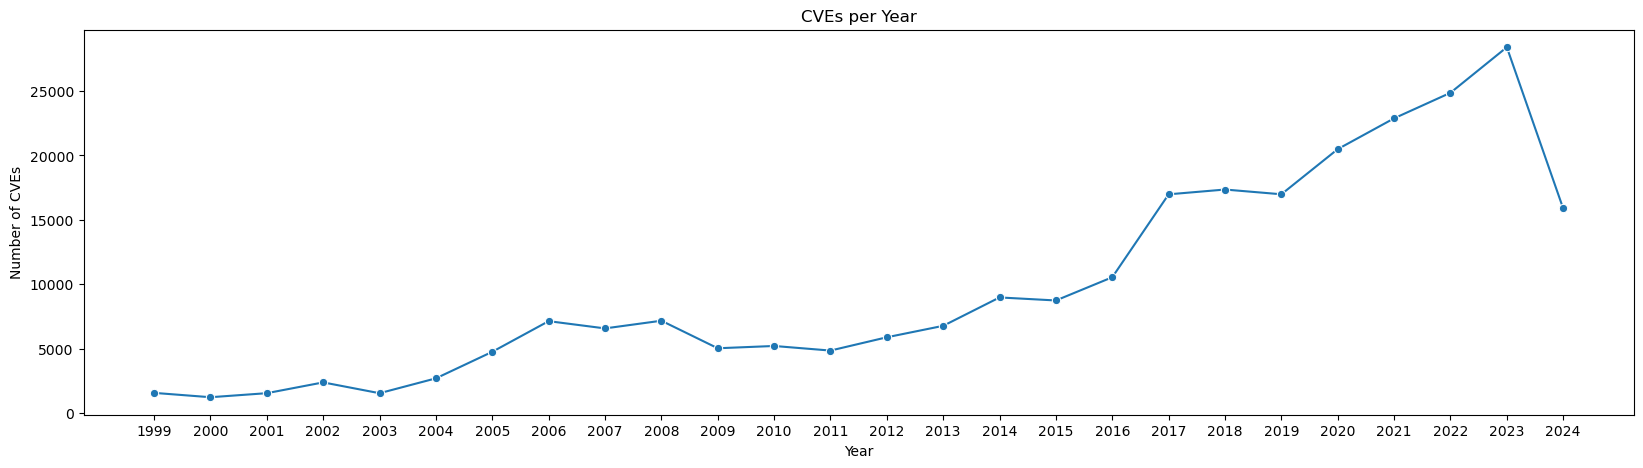

In [9]:
# Extract year from CVE ID
df_temp = df

# Extract the year from the CVE identifier
df_temp['year'] = df_temp['cve_id'].str.split('-').str[1]

# Convert to integer if necessary
df_temp['year'] = df_temp['year'].astype(int)

# Remove specified columns
df_temp = df_temp.drop(columns=['attack_technique', 'similarity', 'attack_mitigation', 'defend_tactic', 'defend_technique'])

# Remove duplicate entries based on CVE ID, keeping the first occurrence
df_cve_agg = df_temp.drop_duplicates(subset=['cve_id'])

years = list(range(df_cve_agg['year'].min(), df_cve_agg['year'].max() + 1))
cves_per_year = df_cve_agg['year'].value_counts().reindex(years, fill_value=0).sort_index()
plt.figure(figsize=(20, 5))
sns.lineplot(x=cves_per_year.index, y=cves_per_year.values, marker='o')
plt.title('CVEs per Year')
plt.xlabel('Year')
plt.ylabel('Number of CVEs')
plt.xticks(cves_per_year.index)
plt.show()

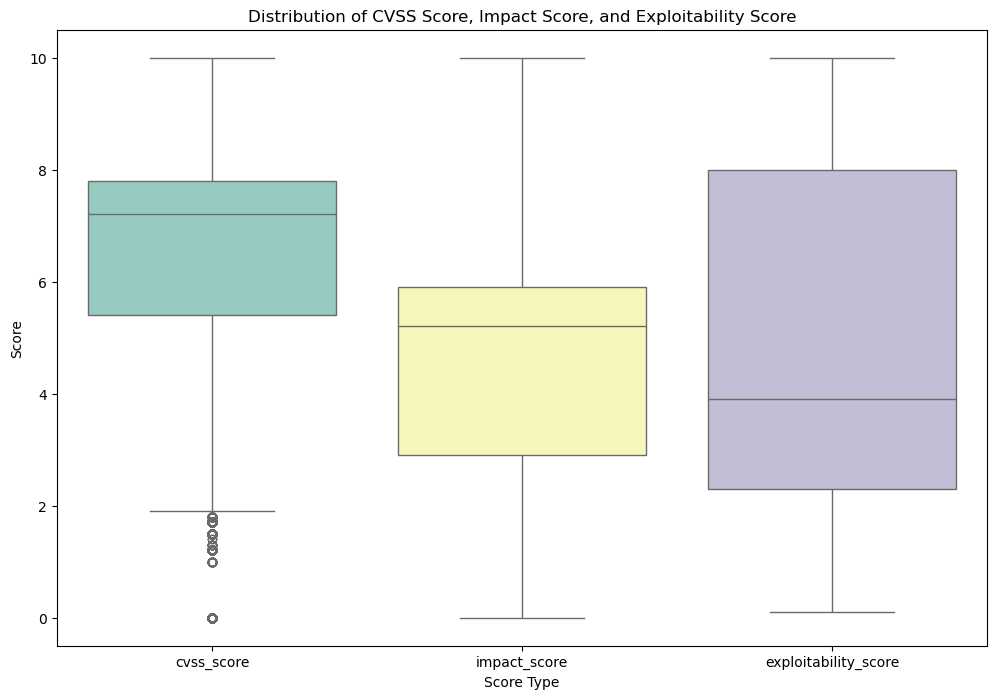

In [10]:
# Plot 4: Box plot showing the CVSS score, impact score, and exploitability score
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[['cvss_score', 'impact_score', 'exploitability_score']], palette='Set3')
plt.title('Distribution of CVSS Score, Impact Score, and Exploitability Score')
plt.xlabel('Score Type')
plt.ylabel('Score')
plt.show()

/var/folders/qb/z7q3w2md0c3c0s29ngj6p0600000gn/T/ipykernel_27542/3969446145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cve_agg, x='cvss_score', y='publisher', palette='Set2', order=medians.index)
/var/folders/qb/z7q3w2md0c3c0s29ngj6p0600000gn/T/ipykernel_27542/3969446145.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(medians[i], i, f'{medians[i]:.2f}', va='center', ha='left', color='black', fontweight='bold')
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be fi

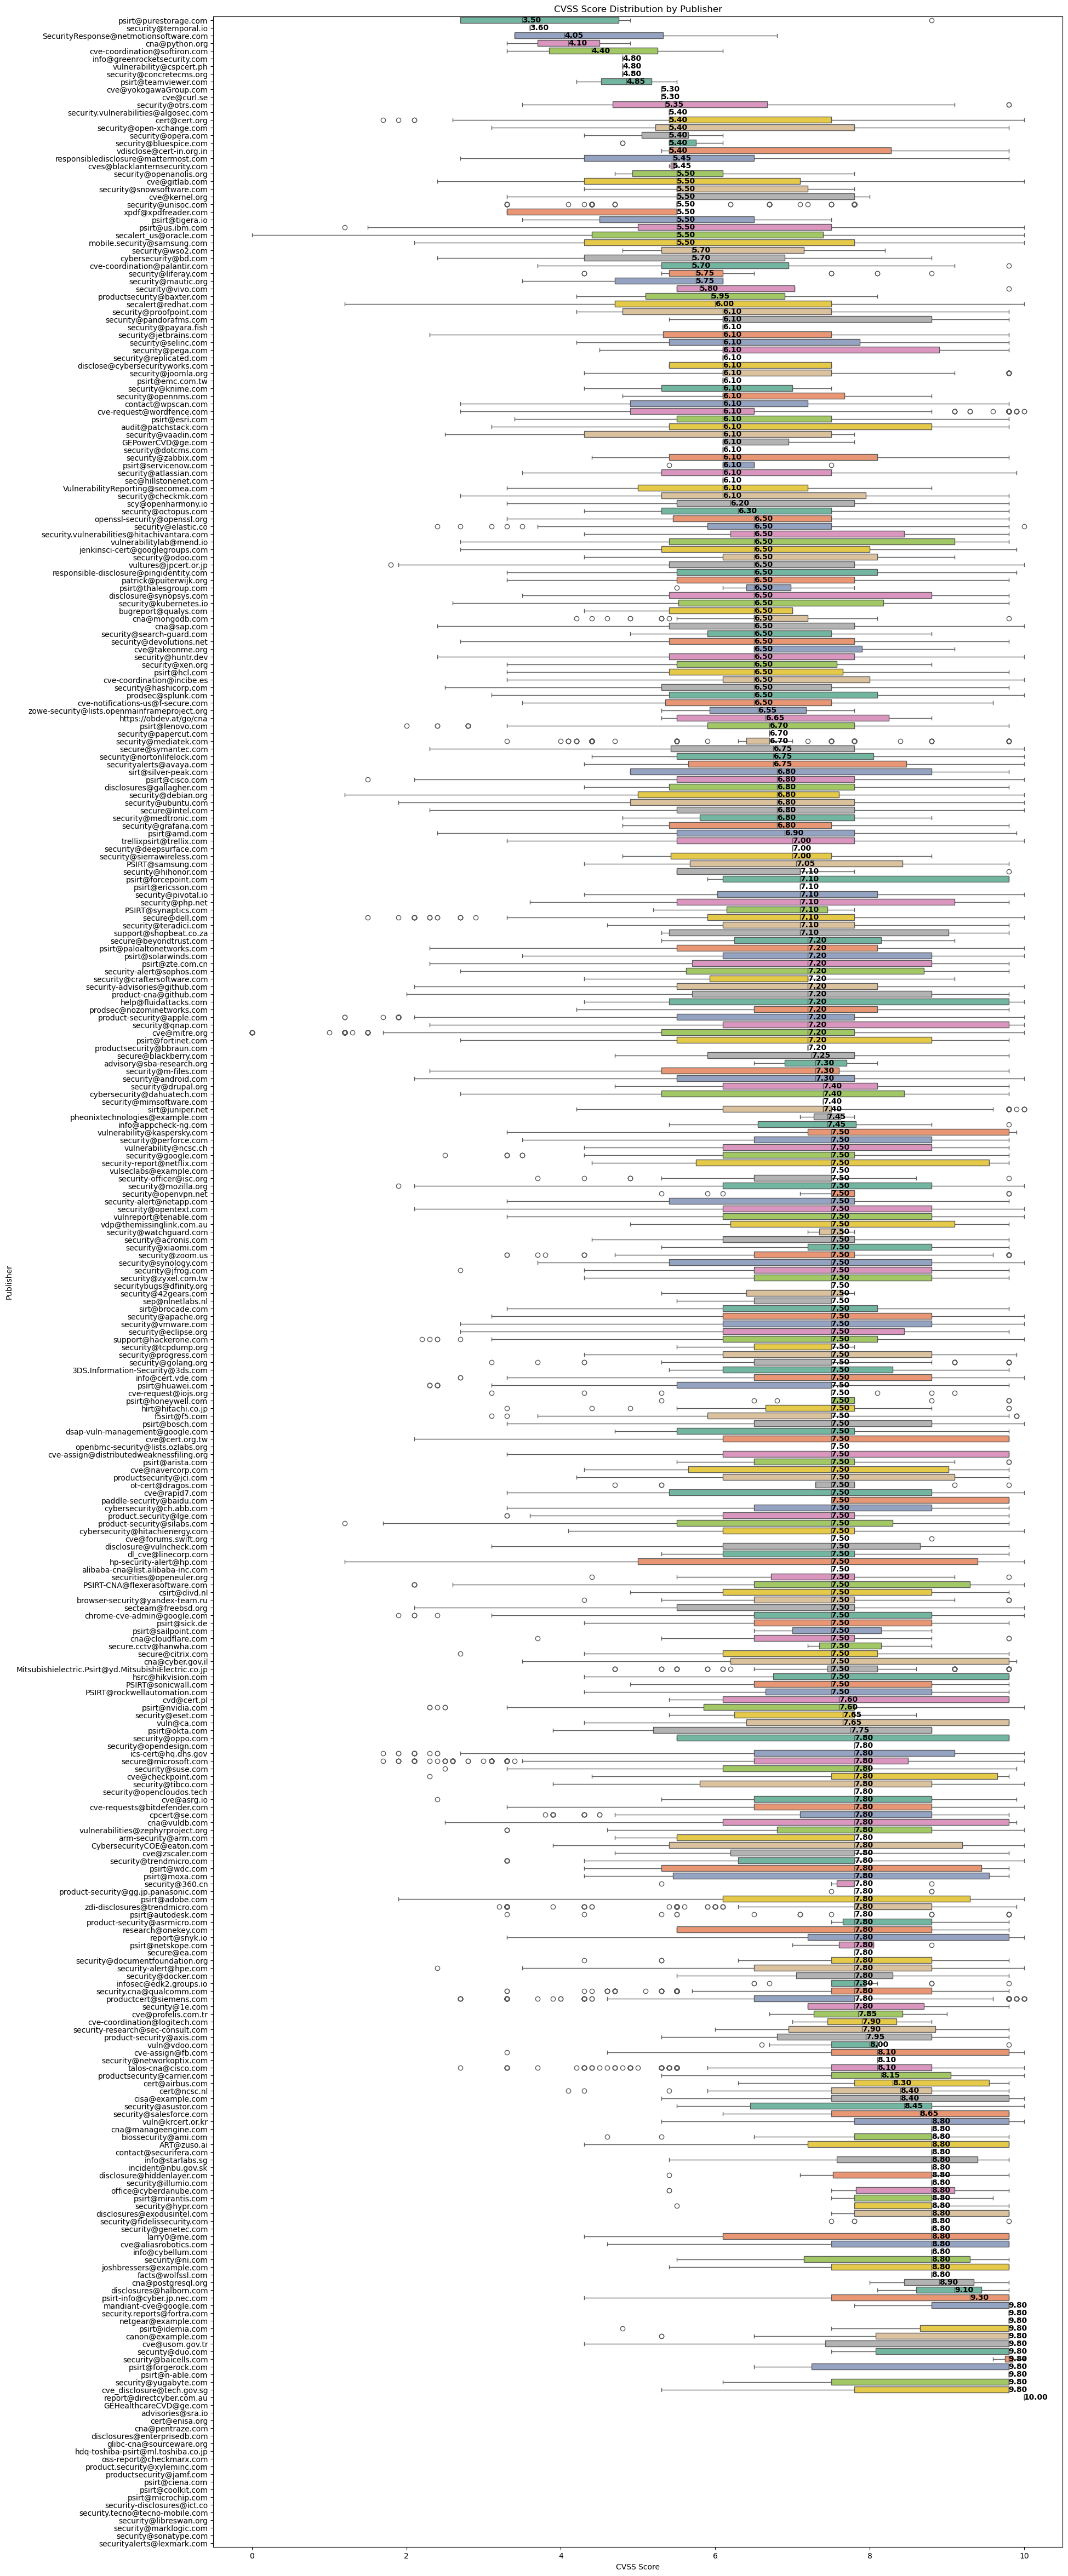

In [11]:
medians = df_cve_agg.groupby('publisher')['cvss_score'].median().sort_values()
plt.figure(figsize=(20, 60))
sns.boxplot(data=df_cve_agg, x='cvss_score', y='publisher', palette='Set2', order=medians.index)
plt.title('CVSS Score Distribution by Publisher')
plt.xlabel('CVSS Score')
plt.ylabel('Publisher')

# Adding median values as labels
for i in range(len(medians)):
    plt.text(medians[i], i, f'{medians[i]:.2f}', va='center', ha='left', color='black', fontweight='bold')

plt.show()

## A.3 Findings


In [13]:
# Function to standardize descriptions that start with "rejected reason"
def standardize_rejected(description):
    if description.lower().startswith("rejected reason"):
        return "Rejected Reason"
    return description

# Filter the data frame for rows where attack_technique is null
df_null_attack_technique = df[df['attack_technique'].isnull()]

# Apply the standardization function to the descriptions
df_null_attack_technique['standardized_description'] = df_null_attack_technique['description'].apply(standardize_rejected)

# Add a 'count' column that shows how many times each standardized description appears
df_null_attack_technique['count'] = df_null_attack_technique.groupby('standardized_description')['standardized_description'].transform('count')

# Drop duplicate descriptions, keeping the first occurrence
df_unique_null_attack_technique = df_null_attack_technique.drop_duplicates(subset=['standardized_description'])

# Sort the data frame by the 'count' column in descending order
df_sorted = df_unique_null_attack_technique.sort_values(by='count', ascending=False)

# Show the top 20 entries and select only the 'cve_id', 'standardized_description', and 'count' columns
top_20_null_attack_technique = df_sorted[['cve_id', 'standardized_description', 'count']].head(100)

print(len(df_sorted))


86597


/var/folders/qb/z7q3w2md0c3c0s29ngj6p0600000gn/T/ipykernel_27542/1798531453.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_null_attack_technique['standardized_description'] = df_null_attack_technique['description'].apply(standardize_rejected)
/var/folders/qb/z7q3w2md0c3c0s29ngj6p0600000gn/T/ipykernel_27542/1798531453.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_null_attack_technique['count'] = df_null_attack_technique.groupby('standardized_description')['standardized_description'].transf

### A.3.1 ATT&CK tactics found in CVE and their kill chain phases

The total percentage is 100.00% and sums up correctly to 100%.
\newcommand{\ReconPct}{1.49\%}
\newcommand{\ResourcePct}{3.63\%}
\newcommand{\InitialPct}{1.79\%}
\newcommand{\ExecutionPct}{1.54\%}
\newcommand{\PersistencePct}{15.92\%}
\newcommand{\PrivilegePct}{12.51\%}
\newcommand{\DefensePct}{21.89\%}
\newcommand{\CredentialPct}{20.74\%}
\newcommand{\DiscoveryPct}{2.54\%}
\newcommand{\LateralPct}{3.51\%}
\newcommand{\CollectionPct}{3.40\%}
\newcommand{\CommandPct}{4.67\%}
\newcommand{\ExfiltrationPct}{0.97\%}
\newcommand{\ImpactPct}{5.41\%}


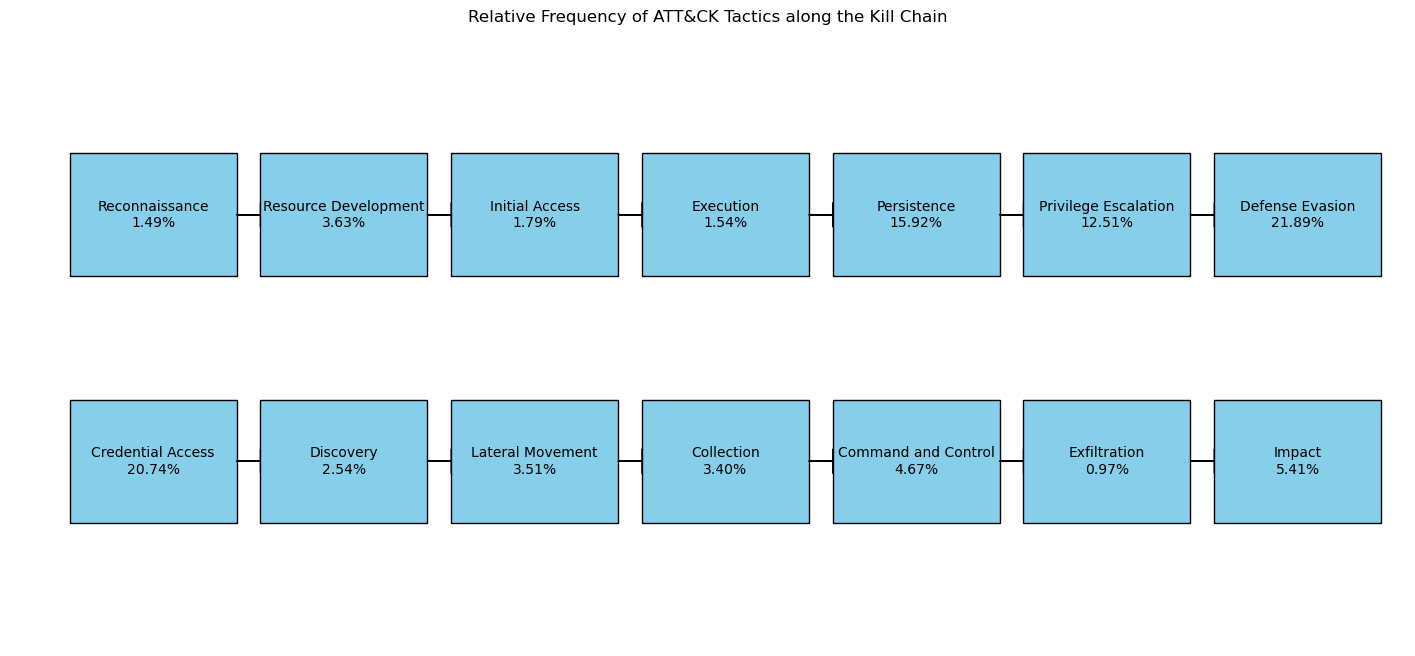

In [15]:
# Step 1: Ensure attack_tactic column contains valid lists
df['attack_tactic'] = df['attack_tactic'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Drop rows with NaN in attack_tactic
df_non_null = df.dropna(subset=['attack_tactic'])

# Step 3: Explode the list of attack_tactic into separate rows
df_exploded = df_non_null.explode('attack_tactic')

# Step 4: Create the mapping between dataset format and the ATT&CK kill chain
tactic_mapping = {
    'reconnaissance': 'Reconnaissance',
    'resource-development': 'Resource Development',
    'initial-access': 'Initial Access',
    'execution': 'Execution',
    'persistence': 'Persistence',
    'privilege-escalation': 'Privilege Escalation',
    'defense-evasion': 'Defense Evasion',
    'credential-access': 'Credential Access',
    'discovery': 'Discovery',
    'lateral-movement': 'Lateral Movement',
    'collection': 'Collection',
    'command-and-control': 'Command and Control',
    'exfiltration': 'Exfiltration',
    'impact': 'Impact'
}

# Step 5: Translate the attack_tactic values using the mapping
df_exploded['attack_tactic_translated'] = df_exploded['attack_tactic'].map(tactic_mapping)

# Step 6: Define the kill chain phases in the correct order
kill_chain_phases = [
    'Reconnaissance', 'Resource Development', 'Initial Access', 'Execution',
    'Persistence', 'Privilege Escalation', 'Defense Evasion', 'Credential Access',
    'Discovery', 'Lateral Movement', 'Collection', 'Command and Control',
    'Exfiltration', 'Impact'
]

# Step 7: Count the occurrences of each translated tactic
tactic_counts_translated = df_exploded['attack_tactic_translated'].value_counts().reindex(kill_chain_phases).fillna(0)

# Step 8: Calculate relative values (percentages)
total_tactics = tactic_counts_translated.sum()
tactic_relative_values = (tactic_counts_translated / total_tactics) * 100

# Check if the total of the relative values equals 100%
total_percentage = tactic_relative_values.sum()
if not np.isclose(total_percentage, 100.0, atol=0.01):
    print(f"Warning: The total percentage is {total_percentage:.2f}% instead of 100.00%")
else:
    print(f"The total percentage is {total_percentage:.2f}% and sums up correctly to 100%.")

# Print the LaTeX commands with the calculated percentages
latex_command_template = "\\newcommand{{\\{name}Pct}}{{{value:.2f}\\%}}"

phase_to_command_name = {
    'Reconnaissance': 'Recon',
    'Resource Development': 'Resource',
    'Initial Access': 'Initial',
    'Execution': 'Execution',
    'Persistence': 'Persistence',
    'Privilege Escalation': 'Privilege',
    'Defense Evasion': 'Defense',
    'Credential Access': 'Credential',
    'Discovery': 'Discovery',
    'Lateral Movement': 'Lateral',
    'Collection': 'Collection',
    'Command and Control': 'Command',
    'Exfiltration': 'Exfiltration',
    'Impact': 'Impact'
}

for phase, value in tactic_relative_values.items():
    latex_command = latex_command_template.format(name=phase_to_command_name[phase], value=value)
    print(latex_command)

# Optional: You can keep the plotting part as well if needed
# Step 9: Plot the kill chain diagram with 7 blocks per row
fig, ax = plt.subplots(figsize=(18, 8))

# Function to create boxes for phases with relative values
def create_boxes_with_percentages(ax, phases, y_base, box_height):
    box_width = 1.4
    margin = 0.2  # Margin between boxes
    positions = np.arange(len(phases)) * (box_width + margin)
    
    for i, (phase, percentage) in enumerate(phases.items()):
        # Create a rectangle for each kill chain phase
        rect = patches.Rectangle((positions[i], y_base), box_width, box_height,
                                 edgecolor='black', facecolor='skyblue')
        ax.add_patch(rect)
        
        # Add the phase label and relative percentage in the middle of the box
        plt.text(positions[i] + box_width / 2, y_base + box_height / 2, f'{phase}\n{percentage:.2f}%', 
                 horizontalalignment='center', verticalalignment='center', fontsize=10)
        
        # Add directed edges (arrows) between the boxes except the last one
        if i < len(phases) - 1:
            ax.arrow(positions[i] + box_width, y_base + box_height / 2, margin, 0, 
                     head_width=0.1, head_length=0.1, fc='black', ec='black')

# Divide the phases into two rows
row_1_phases = {phase: tactic_relative_values[phase] for phase in kill_chain_phases[:7]}
row_2_phases = {phase: tactic_relative_values[phase] for phase in kill_chain_phases[7:]}

# Draw the boxes for the first row (7 boxes) with percentages
create_boxes_with_percentages(ax, row_1_phases, y_base=1.5, box_height=0.5)

# Draw the boxes for the second row (7 boxes) with percentages
create_boxes_with_percentages(ax, row_2_phases, y_base=0.5, box_height=0.5)

# Set limits for the axes
ax.set_xlim(-0.5, 7 * (1.4 + 0.2))  # 7 boxes per row
ax.set_ylim(0, 2.5)

# Remove axes and ticks
ax.axis('off')

# Display the kill chain diagram
plt.title('Relative Frequency of ATT&CK Tactics along the Kill Chain')
plt.show()


### A.3.1 ATT&CK techniques found in CVEs

In [17]:
# Step 6: Prepare data for the Sankey diagram
# We need source (tactics) and target (techniques) with their corresponding counts
tactic_technique_pairs = df_exploded.groupby(['attack_tactic_translated', 'attack_technique']).size().reset_index(name='count')

# Step 7: Create lists for Sankey diagram inputs (nodes and links)
tactics = tactic_technique_pairs['attack_tactic_translated'].unique()
techniques = tactic_technique_pairs['attack_technique'].unique()

# Step 6.1: Print the top 10 most frequent attack techniques
top_techniques = tactic_technique_pairs.groupby('attack_technique')['count'].sum().nlargest(10)
print("Top 10 Most Frequent ATT&CK Techniques:")
print(top_techniques)

# Combine tactics and techniques to create unique nodes
all_nodes = list(tactics) + list(techniques)

# Map each tactic and technique to a node index
node_map = {node: i for i, node in enumerate(all_nodes)}

# Step 8: Calculate relative values for the links
total_count = tactic_technique_pairs['count'].sum()
tactic_technique_pairs['relative_value'] = tactic_technique_pairs['count'] / total_count

# Define the source, target, and value for the links in the Sankey diagram
sources = [node_map[tactic] for tactic in tactic_technique_pairs['attack_tactic_translated']]
targets = [node_map[technique] for technique in tactic_technique_pairs['attack_technique']]
relative_values = tactic_technique_pairs['relative_value'].tolist()

# Step 9: Create the Sankey diagram with relative values
import plotly.graph_objects as go

fig = go.Figure(go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes
    ),
    link=dict(
        source=sources,  # Indices of the source nodes (tactics)
        target=targets,  # Indices of the target nodes (techniques)
        value=relative_values  # Corresponding flow value (relative proportions)
    )
))

# Step 10: Display the Sankey diagram with increased height
fig.update_layout(
    title_text="ATT&CK tactics and their relative distribution on ATT&CK techniques in CVE data.",
    font_size=10,
    height=10000  # Increased height for a larger diagram
)
fig.show()


Top 10 Most Frequent ATT&CK Techniques:
attack_technique
T1556.003    35127
T1556        33174
T1556.006    25962
T1550        21826
T1547.002    21396
T1556.002    21306
T1205.002    20133
T0891        19960
T1100        18084
T1056.004    16928
Name: count, dtype: int64


### A.3.3 ATT&CK technique distribution within CVEs over the years

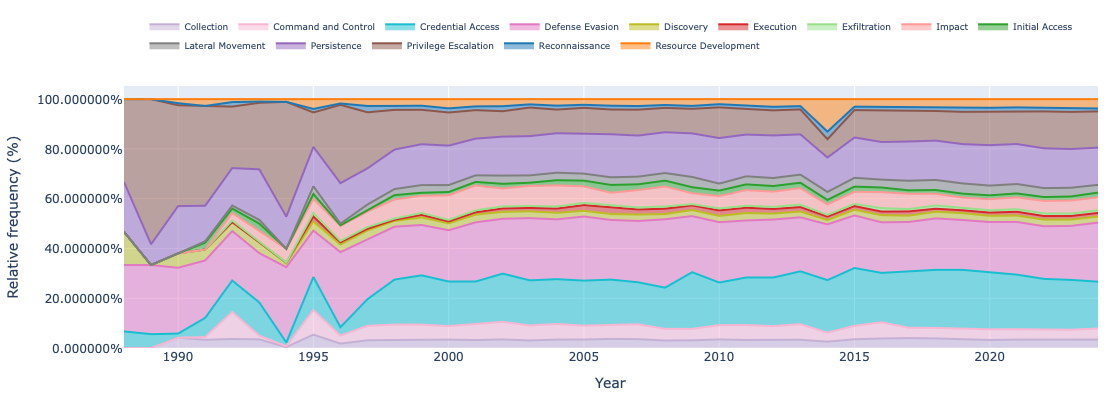

In [19]:
import pandas as pd
import numpy as np
import plotly.express as px
import ast

# Assume the dataframe 'df' is already loaded and prepared

# Step 1: Check and ensure attack_tactic column contains lists
def ensure_list_format(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return x  # Return as-is if it's already a valid string or list
    elif isinstance(x, list):
        return x  # Return as-is if it's already a list
    else:
        return np.nan  # Set invalid values to NaN

df['attack_tactic'] = df['attack_tactic'].apply(ensure_list_format)

# Step 2: Drop rows with NaN in attack_tactic and make a copy to avoid the SettingWithCopyWarning
df_non_null = df.dropna(subset=['attack_tactic']).copy()

# Step 3: Extract the year from the published_date column using .loc[] to avoid the warning
df_non_null.loc[:, 'published_year'] = pd.to_datetime(df_non_null['published_date']).dt.year

# Step 4: Explode the attack_tactic list into separate rows to count each tactic per year
df_exploded = df_non_null.explode('attack_tactic')

# Step 4: Create the mapping between dataset format and the ATT&CK kill chain
tactic_mapping = {
    'reconnaissance': 'Reconnaissance',
    'resource-development': 'Resource Development',
    'initial-access': 'Initial Access',
    'execution': 'Execution',
    'persistence': 'Persistence',
    'privilege-escalation': 'Privilege Escalation',
    'defense-evasion': 'Defense Evasion',
    'credential-access': 'Credential Access',
    'discovery': 'Discovery',
    'lateral-movement': 'Lateral Movement',
    'collection': 'Collection',
    'command-and-control': 'Command and Control',
    'exfiltration': 'Exfiltration',
    'impact': 'Impact'
}

# Step 5: Translate the attack_tactic values using the mapping and filter only mapped values
df_exploded['attack_tactic_translated'] = df_exploded['attack_tactic'].map(tactic_mapping)
df_exploded = df_exploded.dropna(subset=['attack_tactic_translated'])

# Step 6: Group the data by year and translated attack_tactic, and count occurrences
tactic_by_year = df_exploded.groupby(['published_year', 'attack_tactic_translated']).size().reset_index(name='count')

# Step 7: Pivot the data so that each column represents an attack tactic, and each row represents a year
pivot_tactic_year = tactic_by_year.pivot(index='published_year', columns='attack_tactic_translated', values='count').fillna(0)

# Step 8: Normalize the data by year to calculate the relative amount of each attack tactic (in percentage)
pivot_tactic_year_normalized = pivot_tactic_year.div(pivot_tactic_year.sum(axis=1), axis=0).fillna(0)  # Multiply by 100 to get percentage values

color_discrete_map = {
    'Reconnaissance': '#1f77b4',  # Muted Blue
    'Resource Development': '#ff7f0e',  # Orange
    'Initial Access': '#2ca02c',  # Green
    'Execution': '#d62728',  # Red
    'Persistence': '#9467bd',  # Purple
    'Privilege Escalation': '#8c564b',  # Brown
    'Defense Evasion': '#e377c2',  # Pink
    'Credential Access': '#17becf',  # Teal
    'Discovery': '#bcbd22',  # Olive Yellow
    'Lateral Movement': '#7f7f7f',  # Dark Gray
    'Collection': '#c5b0d5',  # Light Purple
    'Command and Control': '#f7b6d2',  # Light Pink
    'Exfiltration': '#98df8a',  # Light Green
    'Impact': '#ff9896',  # Coral Red
}

# Step 9: Plot a Streamgraph using Plotly with distinct colors for each tactic
fig = px.area(
    pivot_tactic_year_normalized,
    x=pivot_tactic_year_normalized.index,
    y=pivot_tactic_year_normalized.columns,
    labels={
        "value": "Relative frequency (%)",  # Update label to show percentage
        "published_year": "Year",
        "attack_tactic_translated": ""
    },
    color_discrete_map=color_discrete_map
)

# Update layout to remove the legend title and position the legend above the figure
fig.update_layout(
    showlegend=True,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.1,  # Position the legend above the figure
        xanchor="center",
        x=0.5,
        font=dict(size=9)  # Set the font size for the legend

    ),
    width=600,
    height=400,
    title={'x': 0.5},  # Center the title
    margin=dict(l=20, r=20, t=60, b=20),  # Adjust margins for better spacing
    yaxis_tickformat='%',  # Set y-axis to show percentage
)
# Display the Streamgraph
fig.show()


### CPE Analysis

In [45]:
# Step 0: Transform cpe_strings from strings to actual lists
df['cpe_strings'] = df['cpe_strings'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 1: Filter out rows with empty CPE strings
df_filtered = df[df['cpe_strings'].apply(lambda x: len(x) > 0 and x != [])].copy()

# Step 2: Categorize CPE Strings by operating system (o), application (a), and hardware (h)
def categorize_cpe(cpe_strings):
    os_cpes = []
    app_cpes = []
    hw_cpes = []
    
    if isinstance(cpe_strings, list):  # Ensure it's a list
        for cpe in cpe_strings:
            if isinstance(cpe, str):
                if cpe.startswith('cpe:2.3:o'):
                    os_cpes.append(cpe)
                elif cpe.startswith('cpe:2.3:a'):
                    app_cpes.append(cpe)
                elif cpe.startswith('cpe:2.3:h'):
                    hw_cpes.append(cpe)
    return os_cpes, app_cpes, hw_cpes

# Apply the categorization function to each row
df_filtered['os_cpes'], df_filtered['app_cpes'], df_filtered['hw_cpes'] = zip(*df_filtered['cpe_strings'].apply(categorize_cpe))

# Keep only necessary columns
df_filtered = df_filtered[['cve_id', 'published_date', 'cpe_strings', 'attack_tactic', 'attack_technique', 'os_cpes', 'app_cpes', 'hw_cpes']]

# Display the filtered DataFrame
df_filtered

,cve_id,published_date,cpe_strings,attack_tactic,attack_technique,os_cpes,app_cpes,hw_cpes
9,CVE-2023-0003,2023-02-08T18:15Z,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[defense-evasion],T1027.011,[cpe:2.3:o:fedoraproject:fedora:37:*:*:*:*:*:*...,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[]
10,CVE-2023-0003,2023-02-08T18:15Z,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[collection],T1530,[cpe:2.3:o:fedoraproject:fedora:37:*:*:*:*:*:*...,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[]
11,CVE-2023-0003,2023-02-08T18:15Z,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[collection],T1005,[cpe:2.3:o:fedoraproject:fedora:37:*:*:*:*:*:*...,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[]
12,CVE-2023-0003,2023-02-08T18:15Z,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[discovery],T1083,[cpe:2.3:o:fedoraproject:fedora:37:*:*:*:*:*:*...,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[]
13,CVE-2023-0003,2023-02-08T18:15Z,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[discovery],T1619,[cpe:2.3:o:fedoraproject:fedora:37:*:*:*:*:*:*...,[cpe:2.3:a:paloaltonetworks:cortex_xsoar:6.8.0...,[]
...,...,...,...,...,...,...,...,...
1126994,CVE-2012-6718,2019-08-28T12:15Z,[cpe:2.3:a:sharebar_project:sharebar:*:*:*:*:*...,NaN,NaN,[],[cpe:2.3:a:sharebar_project:sharebar:*:*:*:*:*...,[]
1126995,CVE-2012-6719,2019-08-28T12:15Z,[cpe:2.3:a:sharebar_project:sharebar:*:*:*:*:*...,NaN,NaN,[],[cpe:2.3:a:sharebar_project:sharebar:*:*:*:*:*...,[]
1126996,CVE-2012-6720,2020-02-11T20:15Z,[cpe:2.3:a:socialengine:socialengine:*:*:*:*:*...,"[initial-access, command-and-control]",T1659,[],[cpe:2.3:a:socialengine:socialengine:*:*:*:*:*...,[]
1126997,CVE-2012-6720,2020-02-11T20:15Z,[cpe:2.3:a:socialengine:socialengine:*:*:*:*:*...,[defense-evasion],T1027.006,[],[cpe:2.3:a:socialengine:socialengine:*:*:*:*:*...,[]


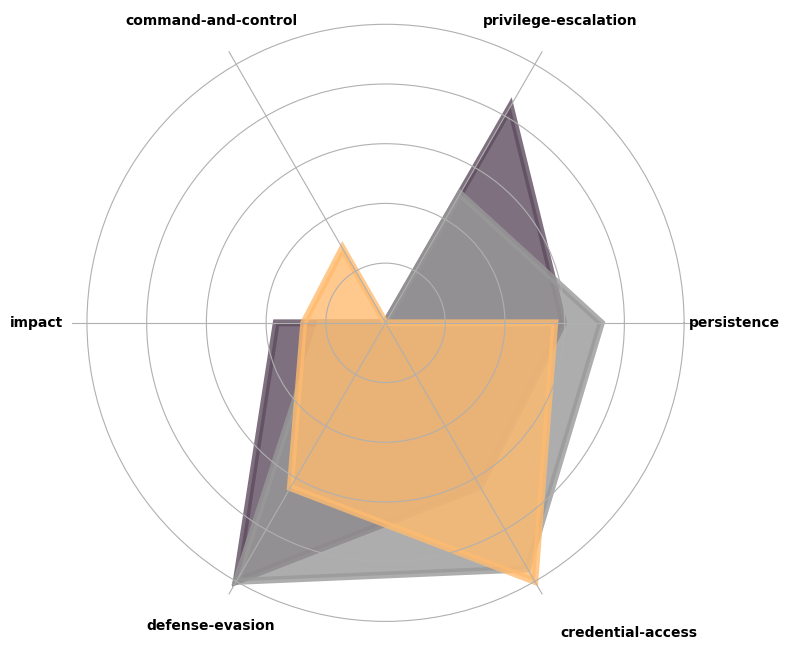

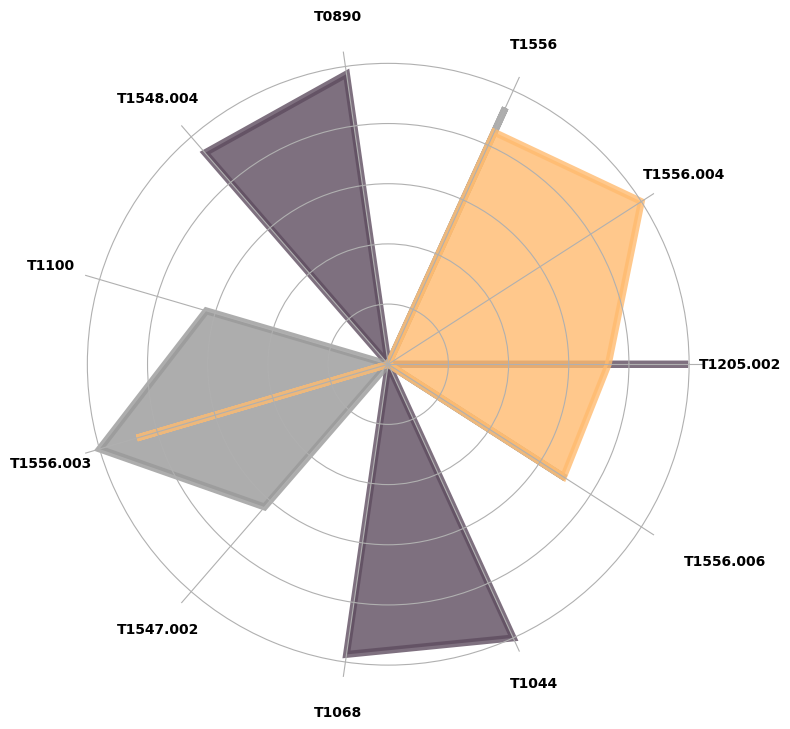

In [137]:
# Step 1: Explode the attack_tactic and attack_technique columns to handle lists
df_filtered_exploded = df_filtered.explode('attack_tactic').explode('attack_technique')

# Step 2: Find the top 3 tactics and techniques for each category
def get_top_values(df, column_name, n=5):
    return df[column_name].value_counts().nlargest(n)

# Extract top 3 for each category (though with only one row, it's just example data)
os_tactics_top3 = get_top_values(df_filtered_exploded[df_filtered_exploded['cpe_strings'].apply(lambda x: any(cpe.startswith('cpe:2.3:o') for cpe in x))], 'attack_tactic')
os_techniques_top3 = get_top_values(df_filtered_exploded[df_filtered_exploded['cpe_strings'].apply(lambda x: any(cpe.startswith('cpe:2.3:o') for cpe in x))], 'attack_technique')

app_tactics_top3 = get_top_values(df_filtered_exploded[df_filtered_exploded['cpe_strings'].apply(lambda x: any(cpe.startswith('cpe:2.3:a') for cpe in x))], 'attack_tactic')
app_techniques_top3 = get_top_values(df_filtered_exploded[df_filtered_exploded['cpe_strings'].apply(lambda x: any(cpe.startswith('cpe:2.3:a') for cpe in x))], 'attack_technique')

hw_tactics_top3 = get_top_values(df_filtered_exploded[df_filtered_exploded['cpe_strings'].apply(lambda x: any(cpe.startswith('cpe:2.3:h') for cpe in x))], 'attack_tactic')
hw_techniques_top3 = get_top_values(df_filtered_exploded[df_filtered_exploded['cpe_strings'].apply(lambda x: any(cpe.startswith('cpe:2.3:h') for cpe in x))], 'attack_technique')

# Step 4: Enhanced Radar chart visualization
output_dir = 'figures'
os.makedirs(output_dir, exist_ok=True)

# Updated radar chart function with internal labels and blue tones
def plot_and_save_radar_chart(categories, os_values, app_values, hw_values, title, filename):
    labels = list(categories)
    num_vars = len(labels)

    # Compute angle of each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # The plot is made in a circular fashion, so we need to "close the loop"
    os_values += os_values[:1]
    app_values += app_values[:1]
    hw_values += hw_values[:1]
    angles += angles[:1]

    # Elegant blue color tones
    blue_colors = ['#5e4c5f', '#999999', '#ffbb6f']

    # Create subplot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Improved plotting with elegant blue tones
    ax.fill(angles, os_values, color=blue_colors[0], alpha=0.8, linewidth=5, edgecolor=blue_colors[0], label='Operating Systems')
    ax.fill(angles, app_values, color=blue_colors[1], alpha=0.8, linewidth=5, edgecolor=blue_colors[1], label='Applications')
    ax.fill(angles, hw_values, color=blue_colors[2], alpha=0.8, linewidth=5, edgecolor=blue_colors[2], label='Hardware')

    # Add grid and enhance the visual clarity
    ax.set_yticklabels([])  # Remove radial labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=20, weight="bold")

    # Add labels inside the chart, next to the lines
    #ax.text(angles[0], os_values[0] - 0.05, 'Operating Systems', color=blue_colors[0], size=12, weight='bold')
    #ax.text(angles[1], app_values[1] - 0.05, 'Applications', color=blue_colors[1], size=12, weight='bold')
    #ax.text(angles[2], hw_values[2] - 1, 'Hardware', color=blue_colors[2], size=12, weight='bold')

    # Calculate rotation angle based on the maximum label length
    max_label_length = max(len(label) for label in labels)
    rotation = 45 if max_label_length <= 10 else 90
    
    ax.set_xticklabels(labels, fontsize=10, rotation=rotation, ha='center', va='center')
    
    for label, angle_rad in zip(ax.get_xticklabels(), angles):
        angle_deg = np.degrees(angle_rad)
        if 0 <= angle_deg < 90:
            ha = 'left'
            va = 'bottom'
        elif 90 <= angle_deg < 180:
            ha = 'right'
            va = 'bottom'
        elif 180 <= angle_deg < 270:
            ha = 'right'
            va = 'top'
        else:
            ha = 'left'
            va = 'top'
            
    # Remove the border around the radar chart
    ax.spines['polar'].set_visible(False)
    
    # Adjust figure layout to ensure consistent size
    fig.tight_layout()
    
    label.set_verticalalignment(va)
    label.set_horizontalalignment(ha)
        
    # Add labels and improve spacing to avoid overlaps
    ax.tick_params(axis='x', pad=15)

    # Customize the title and remove legend for clarity
    plt.title(title, size=16, weight='bold', color='black', y=1.08)

    plt.tight_layout()

    # Save the plot as a PDF in the figures subdirectory
    plt.savefig(os.path.join(output_dir, filename), format='pdf')
    plt.show()

# Normalize function to scale values between 0 and 1
def normalize(values):
    max_value = max(values)
    return [v / max_value for v in values] if max_value > 0 else values

# Prepare data for radar chart and normalize
tactic_categories = list(set(list(os_tactics_top3.keys()) + list(app_tactics_top3.keys()) + list(hw_tactics_top3.keys())))
os_tactic_values = [os_tactics_top3.get(cat, 0) for cat in tactic_categories]
app_tactic_values = [app_tactics_top3.get(cat, 0) for cat in tactic_categories]
hw_tactic_values = [hw_tactics_top3.get(cat, 0) for cat in tactic_categories]

# Normalize the values
os_tactic_values = normalize(os_tactic_values)
app_tactic_values = normalize(app_tactic_values)
hw_tactic_values = normalize(hw_tactic_values)

# Techniques
technique_categories = list(set(list(os_techniques_top3.keys()) + list(app_techniques_top3.keys()) + list(hw_techniques_top3.keys())))
os_technique_values = [os_techniques_top3.get(cat, 0) for cat in technique_categories]
app_technique_values = [app_techniques_top3.get(cat, 0) for cat in technique_categories]
hw_technique_values = [hw_techniques_top3.get(cat, 0) for cat in technique_categories]

# Normalize the values
os_technique_values = normalize(os_technique_values)
app_technique_values = normalize(app_technique_values)
hw_technique_values = normalize(hw_technique_values)

# Plot radar charts for tactics and techniques
plot_and_save_radar_chart(tactic_categories, os_tactic_values, app_tactic_values, hw_tactic_values, '', 'top_tactics_comparison.pdf')
plot_and_save_radar_chart(technique_categories, os_technique_values, app_technique_values, hw_technique_values, '', 'top_techniques_comparison.pdf')

### A.3.4 Co-occurence of ATT&CK tactics

In [ ]:
# Step 1: Filter out rows with missing CVSS scores or attack tactics
df_filtered = df_non_null.dropna(subset=['cvss_score', 'attack_tactic'])

# Step 2: Group by attack tactic and calculate the average CVSS score
tactic_cvss_avg = df_filtered.groupby('attack_tactic')['cvss_score'].mean().reset_index()

# Step 3: Sort the tactics by average CVSS score
tactic_cvss_avg = tactic_cvss_avg.sort_values(by='cvss_score', ascending=False)

# Step 4: Plot the correlation between attack tactics and their average CVSS score
plt.figure(figsize=(10, 6))
sns.barplot(x='cvss_score', y='attack_tactic', data=tactic_cvss_avg, palette='viridis')

# Step 5: Add labels and title
plt.xlabel('Average CVSS Score')
plt.ylabel('Attack Tactic')
plt.title('Correlation between Attack Tactics and Average CVSS Score')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: Filter out NaN values from 'attack_tactic' and ensure all values are lists
df_filtered = df.dropna(subset=['attack_tactic']).copy()  # Make a copy to avoid SettingWithCopyWarning
df_filtered.loc[:, 'attack_tactic'] = df_filtered['attack_tactic'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 3: Translate attack tactics using the mapping and filter only mapped values
def translate_tactics(tactics):
    # Use tactic_mapping to translate each tactic
    return [tactic_mapping[t] for t in tactics if t in tactic_mapping]

df_filtered.loc[:, 'attack_tactic'] = df_filtered['attack_tactic'].apply(translate_tactics)

# Step 4: Remove rows where no valid tactics are left after mapping
df_filtered = df_filtered[df_filtered['attack_tactic'].apply(lambda x: len(x) > 0)]

# Step 5: Grouping by CVE ID and converting attack tactics into a list
# Flatten any nested lists (in case of double nesting)
def flatten(tactic_list):
    return [item for sublist in tactic_list for item in sublist] if isinstance(tactic_list[0], list) else tactic_list

co_occurrence = df_filtered.groupby('cve_id')['attack_tactic'].apply(lambda x: flatten(list(x)))

# Step 6: MultiLabelBinarizer transformation to create binary matrix for attack tactics
mlb = MultiLabelBinarizer()

# Use tqdm to monitor the transformation process
binary_matrix = pd.DataFrame(mlb.fit_transform(co_occurrence), columns=mlb.classes_, index=co_occurrence.index)

# Step 7: Create co-occurrence matrix (how often tactics occur together)
co_occurrence_matrix = binary_matrix.T.dot(binary_matrix)

# Visualize the co-occurrence matrix
plt.figure(figsize=(10, 8))
sns.heatmap(co_occurrence_matrix, cmap="Blues", annot=False)
plt.title('Co-Occurrence matrix of ATT&CK tactics')
plt.show()

In [ ]:
import pandas as pd
import ast

# Assuming 'df' is your original DataFrame that contains 'cve_id' and 'attack_tactic' columns

# Step 1: Ensure 'attack_tactic' is a list (if it's stored as a string in some cases)
df['attack_tactic'] = df['attack_tactic'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Step 2: Drop rows where 'attack_tactic' is NaN or invalid (e.g., not a list)
df_non_null = df.dropna(subset=['attack_tactic'])

# Step 3: Aggregate attack tactics by CVE ID
df_aggregated = df_non_null.groupby('cve_id')['attack_tactic'].agg(lambda x: [item for sublist in x for item in sublist]).reset_index()

# Step 4: Filter CVEs based on the number of unique tactics
df_aggregated['unique_tactics'] = df_aggregated['attack_tactic'].apply(lambda tactics: len(set(tactics)))  # Count unique tactics

# Step 5: Calculate the number and percentage of CVEs with 1 to 14 unique tactics
total_cves = df_aggregated['cve_id'].nunique()

single_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 1]['cve_id'].nunique()
two_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 2]['cve_id'].nunique()
three_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 3]['cve_id'].nunique()
four_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 4]['cve_id'].nunique()
five_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 5]['cve_id'].nunique()
six_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 6]['cve_id'].nunique()
seven_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 7]['cve_id'].nunique()
eight_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 8]['cve_id'].nunique()
nine_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 9]['cve_id'].nunique()
ten_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 10]['cve_id'].nunique()
eleven_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 11]['cve_id'].nunique()
twelve_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 12]['cve_id'].nunique()
thirteen_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 13]['cve_id'].nunique()
fourteen_tactic_cves = df_aggregated[df_aggregated['unique_tactics'] == 14]['cve_id'].nunique()

# Calculate percentages
percentage_single_tactic = (single_tactic_cves / total_cves) * 100
percentage_two_tactic = (two_tactic_cves / total_cves) * 100
percentage_three_tactic = (three_tactic_cves / total_cves) * 100
percentage_four_tactic = (four_tactic_cves / total_cves) * 100
percentage_five_tactic = (five_tactic_cves / total_cves) * 100
percentage_six_tactic = (six_tactic_cves / total_cves) * 100
percentage_seven_tactic = (seven_tactic_cves / total_cves) * 100
percentage_eight_tactic = (eight_tactic_cves / total_cves) * 100
percentage_nine_tactic = (nine_tactic_cves / total_cves) * 100
percentage_ten_tactic = (ten_tactic_cves / total_cves) * 100
percentage_eleven_tactic = (eleven_tactic_cves / total_cves) * 100
percentage_twelve_tactic = (twelve_tactic_cves / total_cves) * 100
percentage_thirteen_tactic = (thirteen_tactic_cves / total_cves) * 100
percentage_fourteen_tactic = (fourteen_tactic_cves / total_cves) * 100

# Step 6: Display the results
print(f"CVEs with only one unique tactic: {single_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with one unique tactic: {percentage_single_tactic:.2f}%")

print(f"CVEs with two unique tactics: {two_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with two unique tactics: {percentage_two_tactic:.2f}%")

print(f"CVEs with three unique tactics: {three_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with three unique tactics: {percentage_three_tactic:.2f}%")

print(f"CVEs with four unique tactics: {four_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with four unique tactics: {percentage_four_tactic:.2f}%")

print(f"CVEs with five unique tactics: {five_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with five unique tactics: {percentage_five_tactic:.2f}%")

print(f"CVEs with six unique tactics: {six_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with six unique tactics: {percentage_six_tactic:.2f}%")

print(f"CVEs with seven unique tactics: {seven_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with seven unique tactics: {percentage_seven_tactic:.2f}%")

print(f"CVEs with eight unique tactics: {eight_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with eight unique tactics: {percentage_eight_tactic:.2f}%")

print(f"CVEs with nine unique tactics: {nine_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with nine unique tactics: {percentage_nine_tactic:.2f}%")

print(f"CVEs with ten unique tactics: {ten_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with ten unique tactics: {percentage_ten_tactic:.2f}%")

print(f"CVEs with eleven unique tactics: {eleven_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with eleven unique tactics: {percentage_eleven_tactic:.2f}%")

print(f"CVEs with twelve unique tactics: {twelve_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with twelve unique tactics: {percentage_twelve_tactic:.2f}%")

print(f"CVEs with thirteen unique tactics: {thirteen_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with thirteen unique tactics: {percentage_thirteen_tactic:.2f}%")

print(f"CVEs with fourteen unique tactics: {fourteen_tactic_cves} out of {total_cves} CVEs")
print(f"Percentage of CVEs with fourteen unique tactics: {percentage_fourteen_tactic:.2f}%")

# Optionally, save the results to a file
# df_aggregated.to_csv("cves_with_tactic_counts.csv", index=False)


In [ ]:

# Step 5: Perform logistic regression for each tactic pair to analyze co-occurrence
regression_results = {}

# Use tqdm to monitor regression progress

for tactic in tqdm(binary_matrix.columns):
    y = binary_matrix[tactic]  # Dependent variable: presence of this tactic
    
    # Independent variables: presence of other tactics
    X = binary_matrix.drop(columns=[tactic])  # Exclude the current tactic from independent variables
    X = sm.add_constant(X)  # Add a constant term for the intercept
    
    # Perform logistic regression
    model = sm.Logit(y, X)
    result = model.fit(disp=0)  # Suppress output
    
    # Store the summary of the regression result
    regression_results[tactic] = result.summary()

# Display regression summaries for each attack tactic
for tactic, summary in regression_results.items():
    print(f"--- Regression Results for {tactic} ---")
    print(summary)
    print("\n")

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from tqdm import tqdm

def create_aggregated_latex_table(binary_matrix, regression_results):
    """
    This function performs logistic regressions on each attack tactic and creates an aggregated
    table of regression coefficients. It then outputs the table in LaTeX format with rotated column names,
    and uses top, mid, and bottom rules for better formatting.
    
    Parameters:
    - binary_matrix: pandas DataFrame with binary data for each tactic (1 if the tactic is present, 0 if not).
    - regression_results: a dictionary to store logistic regression results for each tactic.

    Returns:
    - LaTeX code for the aggregated table with rotated column names and formatted coefficients.
    """
    # Create an empty DataFrame to store the coefficients from each logistic regression model
    aggregated_table = pd.DataFrame(index=binary_matrix.columns, columns=binary_matrix.columns)

    # Loop through each tactic and perform logistic regression
    for tactic in tqdm(binary_matrix.columns):
        y = binary_matrix[tactic]  # Dependent variable: presence of this tactic
        X = binary_matrix.drop(columns=[tactic])  # Exclude the current tactic from independent variables
        X = sm.add_constant(X)  # Add a constant term for the intercept

        # Perform logistic regression
        model = sm.Logit(y, X)
        result = model.fit(disp=0)  # Suppress output
        
        # Extract the coefficients from the result
        coef = result.params
        
        # Store the coefficients in the aggregated table (fill NaN for the current dependent variable)
        for predictor in coef.index:
            if predictor == "const":
                continue
            aggregated_table.at[tactic, predictor] = coef[predictor]

    # Replace NaN values with "-"
    aggregated_table = aggregated_table.fillna("-")
    
    # Create LaTeX code for the table
    latex_code = "\\begin{table*}[ht]\n\\centering\n\\resizebox{\\textwidth}{!}{%\n"
    latex_code += "\\begin{tabular}{l" + "r" * len(binary_matrix.columns) + "}\n"
    
    # Add header with rotated column names
    latex_code += "\\toprule\n"
    latex_code += "& " + " & ".join([f"\\rotatebox{{70}}{{{col}}}" for col in binary_matrix.columns]) + " \\\\\n"
    latex_code += "\\midrule\n"
    
    # Add each row
    for index, row in aggregated_table.iterrows():
        latex_code += f"{index} & "
        
        # Identify the maximum value in the row (ignoring "-")
        numeric_values = row.apply(lambda x: x if x != "-" else np.nan)
        max_value = numeric_values.max()
        
        for col in binary_matrix.columns:
            value = row[col]
            if value == "-":
                latex_code += "-- & "
            else:
                # Format coefficient (four decimal places without removing the leading zero)
                formatted_value = f"{value:.4f}"  # Shorten to 4 decimal places
                
                # Apply bold formatting if the value is the maximum in the row
                if value == max_value:
                    latex_code += f"\\textbf{{{formatted_value}}} & "
                else:
                    latex_code += f"{formatted_value} & "
                    
        latex_code = latex_code.rstrip(" & ")  # Remove trailing "&" for each row
        latex_code += " \\\\\n"
    
    latex_code += "\\bottomrule\n"
    latex_code += "\\end{tabular}}\n\\caption{Logistic Regression Coefficients for Tactic Co-Occurrence.}\n"
    latex_code += "\\label{tab:logistic_regression}\n\\end{table*}"

    # Return the LaTeX code for the table
    return latex_code

# Usage Example
latex_table = create_aggregated_latex_table(binary_matrix, regression_results)

# To view the LaTeX table:
print(latex_table)


# PART B: Analyzing the defenders' playbooks

@Daniel

# PART C: Contrasting attackers and defenders
@Johannes